# El Qang (qg): verificación reproducible

Este notebook reúne solo los resultados del marco **qang** que se sostienen al compararlos contra una referencia independiente (álgebra de Qiskit, `qiskit-addon-cutting` o estadística estándar). **Cada número que aparece en el texto sale de una celda de código de este notebook**; no hay resultados escritos a mano.

Convenciones:

* $qg_Z = \langle\sigma_z\rangle = \cos\theta \in [-1, 1]$
* $qg_S = H\!\left(\tfrac{1+qg_Z}{2}\right) \in [0, 1]$ (entropía de Shannon de la medición en Z, en bits)
* Para un registro de $n$ qubits: $\overline{qg}_Z = \tfrac{1}{n}\sum_i \langle Z_i \rangle$

Qué **no** afirma este notebook: qang no cambia la física ni ahorra energía en el qubit; es un cambio de coordenadas con identidades útiles. Sus aportes están en diagnóstico, en la geometría de la optimización y en el costo de cortar circuitos.

**Contenido**

1. Definiciones e identidades exactas
2. Qué ve y qué no ve qg (ceguera de fase)
3. Diagnóstico de ruido: el par $(qg_S, \overline{qg}_Z)$
4. Optimización: trampa del recorte, gradiente natural y pole damping
5. Circuit knitting: el costo de cortar en unidades qg
6. Estimación con pocos disparos: prior de Haar = uniforme en $qg_Z$
7. QML: codificación qg frente a codificación por ángulo
8. Control con precisión finita: grilla en θ o en qg
9. ¿Qué tipo de ruido es? $\overline{qg}_Z$ frente a XEB
10. Qué no se sostiene (y por qué)
11. Resumen

In [ ]:
%pip install -q qiskit qiskit-aer qiskit-addon-cutting scipy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, SparsePauliOp

SEED = 42
rng = np.random.default_rng(SEED)


def qg_z(theta):
    return np.cos(theta)


def qg_s_from_qg_z(q):
    # Identidad sin ramas: qg_S = H((1 + qg_Z) / 2)
    p = np.clip((1.0 + np.asarray(q, dtype=float)) / 2.0, 0.0, 1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        h = -(np.where(p > 0, p * np.log2(p), 0.0) + np.where(p < 1, (1 - p) * np.log2(1 - p), 0.0))
    return np.maximum(h, 0.0) + 0.0


def transition_probability(q1, q2):
    # |<psi1|psi2>|^2 para dos estados con la misma fase phi
    return 0.5 * (1.0 + q1 * q2 + np.sqrt((1.0 - q1**2) * (1.0 - q2**2)))


def bloch_qg(state):
    # (qg_X, qg_Y, qg_Z) de un estado de 1 qubit (circuito, Statevector o DensityMatrix)
    s = state if isinstance(state, (Statevector, DensityMatrix)) else Statevector(state)
    return tuple(float(s.expectation_value(SparsePauliOp(p)).real) for p in ("X", "Y", "Z"))


print("Listo.")

Listo.


## 1. Definiciones e identidades exactas

Se comprueban contra estados construidos con Qiskit, no contra las mismas fórmulas:

* $qg_Z = P(0) - P(1) = \cos\theta$
* $qg_S = H(P(0))$ coincide con $H\!\left(\tfrac{1+qg_Z}{2}\right)$
* La probabilidad de transición $|\langle\psi_1|\psi_2\rangle|^2 = \tfrac{1}{2}\left(1 + q_1 q_2 + \sqrt{(1-q_1^2)(1-q_2^2)}\right)$ coincide con el solapamiento de los vectores de estado.

In [3]:
thetas = rng.uniform(0, np.pi, 200)
err_z, err_s = 0.0, 0.0
for t in thetas:
    qc = QuantumCircuit(1)
    qc.ry(t, 0)
    p0, p1 = Statevector(qc).probabilities()
    err_z = max(err_z, abs((p0 - p1) - qg_z(t)))
    h = -sum(p * np.log2(p) for p in (p0, p1) if p > 0)
    err_s = max(err_s, abs(h - qg_s_from_qg_z(qg_z(t))))

err_t = 0.0
for t1, t2 in rng.uniform(0, np.pi, (200, 2)):
    a = QuantumCircuit(1); a.ry(t1, 0)
    b = QuantumCircuit(1); b.ry(t2, 0)
    overlap = abs(np.vdot(Statevector(a).data, Statevector(b).data)) ** 2
    err_t = max(err_t, abs(overlap - transition_probability(qg_z(t1), qg_z(t2))))

print(f"Error máximo qg_Z vs P(0)-P(1):            {err_z:.1e}")
print(f"Error máximo qg_S vs entropía de Qiskit:    {err_s:.1e}")
print(f"Error máximo transición vs solapamiento:    {err_t:.1e}  (200 pares aleatorios)")
print()
for name, t in [("|0>", 0.0), ("estado T (pi/4)", np.pi / 4), ("ecuador |+>", np.pi / 2), ("|1>", np.pi)]:
    print(f"{name:16s} qg_Z = {qg_z(t):+.4f}   qg_S = {qg_s_from_qg_z(qg_z(t)):.4f}")

Error máximo qg_Z vs P(0)-P(1):            2.2e-16
Error máximo qg_S vs entropía de Qiskit:    8.3e-16
Error máximo transición vs solapamiento:    7.8e-16  (200 pares aleatorios)

|0>              qg_Z = +1.0000   qg_S = 0.0000
estado T (pi/4)  qg_Z = +0.7071   qg_S = 0.6009
ecuador |+>      qg_Z = +0.0000   qg_S = 1.0000
|1>              qg_Z = -1.0000   qg_S = 0.0000


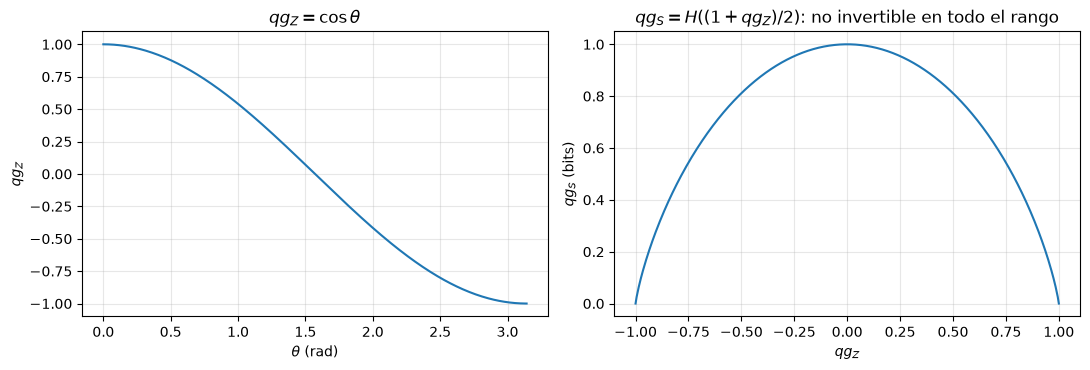

In [4]:
q = np.linspace(-1, 1, 401)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
th = np.linspace(0, np.pi, 400)
ax[0].plot(th, np.cos(th))
ax[0].set_xlabel(r"$\theta$ (rad)"); ax[0].set_ylabel(r"$qg_Z$"); ax[0].set_title(r"$qg_Z = \cos\theta$")
ax[1].plot(q, qg_s_from_qg_z(q))
ax[1].set_xlabel(r"$qg_Z$"); ax[1].set_ylabel(r"$qg_S$ (bits)"); ax[1].set_title(r"$qg_S = H((1+qg_Z)/2)$: no invertible en todo el rango")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura.** $qg_S$ es simétrica: $qg_Z = +q$ y $qg_Z = -q$ dan la misma entropía. Por eso $qg_S$ sola no alcanza para reconstruir el estado; hace falta el signo de $qg_Z$.

## 2. Qué ve y qué no ve qg

$qg_Z$ y $qg_S$ se calculan con mediciones en Z. Todo lo que solo cambia la fase $\varphi$ les resulta invisible: la precesión de Larmor, una compuerta $R_z$ o las fases que genera una CZ. Para verlo hacen falta las otras dos componentes, $qg_X = \langle\sigma_x\rangle$ y $qg_Y = \langle\sigma_y\rangle$.

In [5]:
print(f"{'phi':>6} | {'qg_X':>7} {'qg_Y':>7} {'qg_Z':>7} | {'qg_S':>6}")
for phi in [0, np.pi / 4, np.pi / 2, np.pi, 3 * np.pi / 2]:
    qc = QuantumCircuit(1)
    qc.ry(np.pi / 2, 0)
    qc.rz(phi, 0)
    x, y, z = bloch_qg(qc)
    print(f"{phi:6.3f} | {x:+7.3f} {y:+7.3f} {z:+7.3f} | {qg_s_from_qg_z(z):6.3f}")

   phi |    qg_X    qg_Y    qg_Z |   qg_S
 0.000 |  +1.000  +0.000  +0.000 |  1.000
 0.785 |  +0.707  +0.707  +0.000 |  1.000
 1.571 |  +0.000  +1.000  +0.000 |  1.000
 3.142 |  -1.000  +0.000  +0.000 |  1.000
 4.712 |  -0.000  -1.000  +0.000 |  1.000


**Lectura.** Al girar $\varphi$, $qg_X$ y $qg_Y$ cambian, mientras $qg_Z$ y $qg_S$ quedan fijos. No es una falla de qg: es un límite de cualquier métrica basada solo en mediciones en Z, y conviene declararlo.

## 3. Diagnóstico de ruido: el par $(qg_S, \overline{qg}_Z)$

**3a. Relajación T1 (amplitude damping).** Se parte de $|1\rangle$ y se aplica un canal de amortiguamiento de amplitud con probabilidad $\gamma$. $qg_S$ sube y después baja: dos niveles de ruido muy distintos pueden dar la misma $qg_S$. $qg_Z$, en cambio, es monótono y los distingue.

gamma = 0.2:  qg_S = 0.7219   qg_Z = -0.6000
gamma = 0.8:  qg_S = 0.7219   qg_Z = +0.6000
-> misma qg_S, qg_Z opuesto: el par distingue lo que qg_S sola confunde.


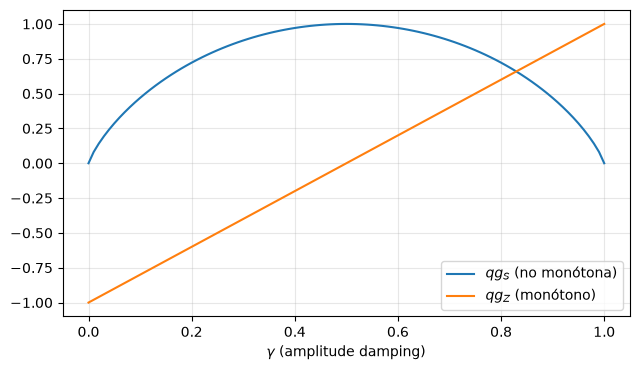

In [6]:
from qiskit_aer.noise import amplitude_damping_error, phase_damping_error
from qiskit.quantum_info import Kraus


def apply_channel(rho, err):
    return rho.evolve(Kraus(err.to_quantumchannel()))


rho1 = DensityMatrix.from_label("1")
gammas = np.linspace(0, 1, 101)
qs, ss = [], []
for g in gammas:
    r = apply_channel(rho1, amplitude_damping_error(g))
    z = bloch_qg(r)[2]
    qs.append(z); ss.append(qg_s_from_qg_z(z))
qs, ss = np.array(qs), np.array(ss)

for g in (0.2, 0.8):
    i = int(round(g * 100))
    print(f"gamma = {g:.1f}:  qg_S = {ss[i]:.4f}   qg_Z = {qs[i]:+.4f}")
print("-> misma qg_S, qg_Z opuesto: el par distingue lo que qg_S sola confunde.")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(gammas, ss, label=r"$qg_S$ (no monótona)")
ax.plot(gammas, qs, label=r"$qg_Z$ (monótono)")
ax.set_xlabel(r"$\gamma$ (amplitude damping)"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

**3b. Desfasaje en la lectura vs. dentro del circuito.** Se prepara $|+\rangle$ y se aplica desfasaje de intensidad $\lambda$:

* **en la lectura** (el canal va justo antes de medir): no cambia las poblaciones, así que $qg_S$ no se mueve;
* **dentro del circuito** (después del canal viene una Hadamard): la coherencia perdida pasa a las poblaciones, y $qg_S$ **sube** de 0 a 1.

In [7]:
plus = DensityMatrix.from_label("+")
print(f"{'lambda':>7} | {'qg_S lectura':>12} | {'qg_S interno (H después)':>24}")
for lam in [0.0, 0.3, 0.7, 1.0]:
    r = apply_channel(plus, phase_damping_error(lam))
    s_read = qg_s_from_qg_z(bloch_qg(r)[2])
    qc = QuantumCircuit(1); qc.h(0)
    r_int = r.evolve(qc)
    s_int = qg_s_from_qg_z(bloch_qg(r_int)[2])
    print(f"{lam:7.2f} | {s_read:12.4f} | {s_int:24.4f}")

 lambda | qg_S lectura | qg_S interno (H después)
   0.00 |       1.0000 |                   0.0000
   0.30 |       1.0000 |                   0.4080
   0.70 |       1.0000 |                   0.7712
   1.00 |       1.0000 |                   1.0000


**Lectura.** El desfasaje en la lectura es exactamente invisible para $qg_S$, a cualquier intensidad. El mismo desfasaje dentro del circuito sí se ve. Esto separa las dos fuentes de error con un solo tipo de medición, aunque solo cuando hay compuertas después del canal. El repositorio muestra el mismo efecto en circuitos de Quantum Volume de 4 qubits (§10.4, Findings A y B).

## 4. Optimización

Se usa el paisaje de un qubit $E(\theta) = h_z\cos\theta + h_x\sin\theta$, cuyo mínimo exacto es $-\sqrt{h_z^2+h_x^2}$.

### 4a. La trampa del recorte $\theta \in [0, \pi]$

Con $h_z = 1$ y $h_x = 0.4$, el mínimo está en $\theta < 0$. Si se recorta $\theta$ a $[0, \pi]$ (o, lo que es lo mismo, se parametriza con $\theta = \arccos(qg_Z)$), el mínimo queda fuera de alcance y el optimizador se traba en el polo.

In [8]:
def landscape(hz, hx):
    E = lambda t: hz * np.cos(t) + hx * np.sin(t)
    dE = lambda t: -hz * np.sin(t) + hx * np.cos(t)
    return E, dE, -np.hypot(hz, hx)


E, dE, Emin = landscape(1.0, 0.4)
for clip in (True, False):
    t = 0.01
    for _ in range(35):
        t -= 0.7 * dE(t)
        if clip:
            t = float(np.clip(t, 0.0, np.pi))
    print(f"Descenso en theta, lr=0.7, recorte a [0, pi] = {clip!s:5s}: E = {E(t):+.6f}  (error {abs(E(t) - Emin):.1e})")

Descenso en theta, lr=0.7, recorte a [0, pi] = True : E = +1.000000  (error 2.1e+00)
Descenso en theta, lr=0.7, recorte a [0, pi] = False: E = -1.077033  (error 0.0e+00)


**Lectura.** El problema es el recorte, no el descenso por gradiente: sin recorte converge exacto. Es la "trampa del rango de arccos" que el repositorio documenta en H₂ (§8.2).

### 4b. El gradiente natural en qg es el descenso común en θ

La información de Fisher cuántica de $R_y(\theta)|0\rangle$ en la coordenada $qg_Z$ es proporcional a $F(qg_Z) = \dfrac{1}{1 - qg_Z^2}$, y $\dfrac{dE}{dqg_Z} = -\dfrac{1}{\sin\theta}\dfrac{dE}{d\theta}$. El paso natural queda

$$\Delta qg_Z = -\eta\,(1 - qg_Z^2)\,\frac{dE}{dqg_Z} = \eta\,\sin\theta\,\frac{dE}{d\theta} \;\Longrightarrow\; \Delta\theta \approx -\eta\,\frac{dE}{d\theta}.$$

O sea: **el gradiente natural en qg reproduce el descenso común en θ.** No es una ventaja sobre θ. Lo que explica es por qué el descenso *crudo* en qg es el caso patológico. A continuación se verifica con un mínimo dentro de $(0, \pi)$ ($h_x = -0.4$).

In [9]:
E, dE, Emin = landscape(1.0, -0.4)
t, q = 1.0, np.cos(1.0)
max_gap = 0.0
for _ in range(300):
    t -= 0.05 * dE(t)
    th = np.arccos(q)
    q -= 0.05 * (1 - q * q) * (-(1 / np.sin(th)) * dE(th))
    max_gap = max(max_gap, abs(np.cos(t) - q))
print(f"Descenso en theta   -> qg_Z final = {np.cos(t):+.6f}")
print(f"Natural en qg_Z     -> qg_Z final = {q:+.6f}")
print(f"Exacto              -> qg_Z       = {-1 / np.hypot(1, 0.4):+.6f}")
print(f"Máxima diferencia entre trayectorias: {max_gap:.1e}  (orden lr^2, se achica con lr)")

Descenso en theta   -> qg_Z final = -0.928477
Natural en qg_Z     -> qg_Z final = -0.928477
Exacto              -> qg_Z       = -0.928477
Máxima diferencia entre trayectorias: 4.5e-03  (orden lr^2, se achica con lr)


### 4c. Pole damping: ventaja y costo

El pole damping escala el paso en θ por $\max(|\sin\theta|, \varepsilon)$ con $\varepsilon = 0.05$. Para ver cuándo ayuda y cuándo cuesta, se corre con $\theta_0 = 0.02$ (cerca del polo), sin recorte, en el paisaje $h_z = 0.5504$, $h_x = 0.1809$. El criterio de convergencia es error $< 10^{-6}$ en a lo sumo 500 pasos.

In [10]:
E, dE, Emin = landscape(0.5504, 0.1809)


def steps_to_converge(lr, damped, t0=0.02, steps=500, tol=1e-6):
    t = t0
    for k in range(steps):
        if abs(E(t) - Emin) < tol:
            return k
        f = max(abs(np.sin(t)), 0.05) if damped else 1.0
        t -= lr * f * dE(t)
    return None


fmt = lambda k: "no converge" if k is None else f"{k} pasos"
print(f"{'lr':>5} | {'descenso común':>15} | {'pole damping':>15}")
for lr in [0.5, 1, 2, 3, 4, 5, 6, 8, 10]:
    print(f"{lr:5} | {fmt(steps_to_converge(lr, False)):>15} | {fmt(steps_to_converge(lr, True)):>15}")

   lr |  descenso común |    pole damping
  0.5 |        28 pasos |        92 pasos
    1 |        13 pasos |        45 pasos
    2 |         6 pasos |        22 pasos
    3 |        21 pasos |        24 pasos
    4 |     no converge |        10 pasos
    5 |     no converge |        13 pasos
    6 |     no converge |     no converge
    8 |     no converge |        30 pasos
   10 |     no converge |        38 pasos


In [11]:
# Estadística: 300 paisajes aleatorios por lr, arranque a < 0.05 rad de un polo
def success_rate(lr, damped, n=300, seed=1):
    r = np.random.default_rng(seed)
    ok = 0
    for _ in range(n):
        a, b = r.normal(size=2)
        t = r.choice([0.0, np.pi]) + r.choice([-1, 1]) * r.uniform(0, 0.05)
        Ef, dEf, Em = landscape(a, b)
        for _ in range(500):
            f = max(abs(np.sin(t)), 0.05) if damped else 1.0
            t -= lr * f * dEf(t)
        ok += abs(Ef(t) - Em) < 1e-4
    return ok / n


print(f"{'lr':>4} | {'común':>6} | {'pole damping':>12}")
for lr in [1, 3, 5, 8]:
    print(f"{lr:4} | {success_rate(lr, False):6.1%} | {success_rate(lr, True):12.1%}")

  lr |  común | pole damping


   1 |  85.7% |        96.0%


   3 |  19.0% |        43.0%


   5 |   9.3% |        27.0%


   8 |   3.0% |        15.7%


**Lectura.** Con tasas de aprendizaje moderadas (0.5 a 2), el pole damping **cuesta** unas 3.5 veces más pasos. Con tasas agresivas converge donde el descenso común diverge, aunque no siempre (en la tabla falla en lr = 6). Es un estabilizador con costo, no una mejora gratis; coincide con el §9 del repositorio.

## 5. Circuit knitting: el costo de cortar en unidades qg

Cortar una compuerta de dos qubits la reemplaza por una combinación de circuitos locales (descomposición cuasi-probabilística). El precio es que hay que multiplicar los disparos por $\gamma^2$. Para $R_{ZZ}(\theta)$ el valor óptimo conocido es $\gamma = 1 + 2|\sin\theta|$. Escrito en la unidad qg del ángulo de la compuerta, $qg = \cos\theta$:

$$\boxed{\gamma = 1 + 2\sqrt{1 - qg^2}}$$

Se verifica contra la librería oficial `qiskit-addon-cutting`.

In [12]:
from qiskit.circuit.library import RZZGate
from qiskit_addon_cutting.qpd import QPDBasis

print(f"{'theta':>6} {'qg':>7} | {'gamma (librería)':>16} {'1+2*sqrt(1-qg^2)':>17} | {'disparos x gamma^2':>18}")
for th in [0.1, np.pi / 6, np.pi / 4, np.pi / 3, np.pi / 2]:
    g_lib = QPDBasis.from_instruction(RZZGate(th)).overhead ** 0.5
    q = np.cos(th)
    g_qg = 1 + 2 * np.sqrt(1 - q**2)
    print(f"{th:6.3f} {q:+7.4f} | {g_lib:16.4f} {g_qg:17.4f} | {g_lib**2:18.2f}")

 theta      qg | gamma (librería)  1+2*sqrt(1-qg^2) | disparos x gamma^2
 0.100 +0.9950 |           1.1997            1.1997 |               1.44
 0.524 +0.8660 |           2.0000            2.0000 |               4.00
 0.785 +0.7071 |           2.4142            2.4142 |               5.83
 1.047 +0.5000 |           2.7321            2.7321 |               7.46
 1.571 +0.0000 |           3.0000            3.0000 |               9.00


Ahora un corte real: un circuito de 2 qubits con $R_{ZZ}(\theta)$ se parte en dos subcircuitos de 1 qubit, se simulan por separado y se reconstruyen los valores esperados. Se eligen observables que **sí dependen de θ**, como $\langle X_0\rangle$. $\langle ZZ\rangle$ no sirve para probar un corte de $R_{ZZ}$, porque conmuta con la compuerta y no depende de θ.

In [13]:
from qiskit_addon_cutting import partition_problem, generate_cutting_experiments, reconstruct_expectation_values
from qiskit_aer.primitives import SamplerV2

observables = SparsePauliOp(["IX", "XI", "XX", "ZZ"])
print(f"{'theta':>6} | {'observable':>10} {'exacto':>8} {'cortado':>8} | gamma")
for th in [0.3, np.pi / 4, np.pi / 2]:
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.ry(0.7, 1)
    qc.rzz(th, 0, 1)
    exact = [Statevector(qc).expectation_value(SparsePauliOp(p)).real for p in observables.paulis.to_labels()]
    part = partition_problem(circuit=qc, partition_labels="AB", observables=observables.paulis)
    subexp, coeffs = generate_cutting_experiments(
        circuits=part.subcircuits, observables=part.subobservables, num_samples=np.inf)
    sampler = SamplerV2(seed=SEED)
    results = {label: sampler.run(subexp[label], shots=20000).result() for label in subexp}
    rec = reconstruct_expectation_values(results, coeffs, part.subobservables)
    gamma = sum(abs(c) for c, _ in coeffs)
    for lab, e, r_ in zip(observables.paulis.to_labels(), exact, rec):
        print(f"{th:6.3f} | {lab:>10} {e:+8.3f} {r_:+8.3f} | {gamma:.3f}")
    print("-" * 48)

 theta | observable   exacto  cortado | gamma


 0.300 |         IX   +0.955   +0.957 | 1.591
 0.300 |         XI   +0.615   +0.617 | 1.591
 0.300 |         XX   +0.644   +0.645 | 1.591
 0.300 |         ZZ   +0.000   -0.006 | 1.591
------------------------------------------------


 0.785 |         IX   +0.707   +0.711 | 2.414
 0.785 |         XI   +0.456   +0.458 | 2.414
 0.785 |         XX   +0.644   +0.645 | 2.414
 0.785 |         ZZ   +0.000   -0.002 | 2.414
------------------------------------------------


 1.571 |         IX   +0.000   +0.006 | 3.000
 1.571 |         XI   +0.000   +0.004 | 3.000
 1.571 |         XX   +0.644   +0.644 | 3.000
 1.571 |         ZZ   +0.000   +0.003 | 3.000
------------------------------------------------


**Lectura.** La reconstrucción coincide con el valor exacto dentro del ruido de muestreo, y la suma $\sum|c_j|$ de la librería da justo $1 + 2\sqrt{1-qg^2}$. En unidades qg, el costo de cortar depende solo de la "parte transversal" $\sqrt{1-qg^2}$ del ángulo de la compuerta: es nulo en $qg = \pm 1$ y máximo ($\gamma^2 = 9$) en $qg = 0$. Además, en este circuito $\langle X_0\rangle = \cos\theta = qg$: el propio observable mide la qg de la compuerta.

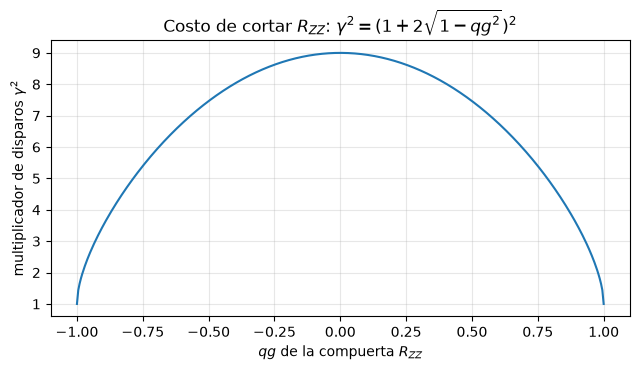

In [14]:
qv = np.linspace(-1, 1, 401)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(qv, (1 + 2 * np.sqrt(1 - qv**2)) ** 2)
ax.set_xlabel(r"$qg$ de la compuerta $R_{ZZ}$"); ax.set_ylabel(r"multiplicador de disparos $\gamma^2$")
ax.set_title(r"Costo de cortar $R_{ZZ}$: $\gamma^2 = (1 + 2\sqrt{1-qg^2})^2$"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Estimación con pocos disparos: prior de Haar = uniforme en $qg_Z$

Si el estado es aleatorio según la medida de Haar, $qg_Z$ queda **uniforme en $[-1, 1]$** (teorema de la "caja de sombreros" de Arquímedes). Por eso el prior natural es uniforme en $qg_Z$, o sea $p_0 \sim \mathrm{Beta}(1,1)$. Con $k$ ceros en $N$ disparos, la posterior es $\mathrm{Beta}(k+1, N-k+1)$. Primero se comprueba la uniformidad.

In [15]:
def haar_qubit(n, r):
    v = r.normal(size=(n, 2)) + 1j * r.normal(size=(n, 2))
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return np.abs(v[:, 0]) ** 2 - np.abs(v[:, 1]) ** 2


qh = haar_qubit(200_000, rng)
hist, _ = np.histogram(qh, bins=10, range=(-1, 1))
print("Frecuencia relativa de qg_Z por décimo del intervalo [-1, 1] (uniforme = 0.100):")
print(np.round(hist / hist.sum(), 3))

Frecuencia relativa de qg_Z por décimo del intervalo [-1, 1] (uniforme = 0.100):
[0.099 0.099 0.1   0.1   0.099 0.1   0.1   0.1   0.101 0.102]


Ahora se comparan tres intervalos del 95% para $p_0$ con $N = 50$ disparos: el método delta (el ingenuo), el de Wilson (el estándar frecuentista) y el bayesiano con prior de Haar. Se mide la **cobertura** (cuántas veces el intervalo contiene el valor real; debería ser ≈ 95%) y el ancho medio.

In [16]:
def wilson(k, n, z=1.96):
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return c - h, c + h


N, trials = 50, 20000
r = np.random.default_rng(SEED)
cases = {
    "estados de Haar": (1 + haar_qubit(trials, r)) / 2,
    "cerca del polo (theta = 0.08)": np.full(trials, np.cos(0.04) ** 2),
}
print(f"{'caso':30s} {'método':11s} {'cobertura':>9} {'ancho':>7}")
for name, p in cases.items():
    k = r.binomial(N, p)
    ph = k / N
    se = np.sqrt(ph * (1 - ph) / N)
    intervals = {
        "delta": (ph - 1.96 * se, ph + 1.96 * se),
        "Wilson": wilson(k, N),
        "Bayes-Haar": (beta.ppf(0.025, k + 1, N - k + 1), beta.ppf(0.975, k + 1, N - k + 1)),
    }
    for m, (lo, hi) in intervals.items():
        print(f"{name:30s} {m:11s} {np.mean((lo <= p) & (p <= hi)):9.1%} {np.mean(hi - lo):7.3f}")
    if name.startswith("estados"):
        q_true = 2 * p - 1
        mse_ml = np.mean((2 * ph - 1 - q_true) ** 2)
        mse_b = np.mean((2 * (k + 1) / (N + 2) - 1 - q_true) ** 2)
        print(f"{'':30s} error cuadrático medio de qg_Z: frecuencia simple {mse_ml:.5f} | Bayes-Haar {mse_b:.5f} "
              f"({(1 - mse_b / mse_ml):.1%} menor)")

caso                           método      cobertura   ancho
estados de Haar                delta           89.8%   0.212
estados de Haar                Wilson          95.1%   0.212
estados de Haar                Bayes-Haar      94.9%   0.212
                               error cuadrático medio de qg_Z: frecuencia simple 0.01344 | Bayes-Haar 0.01292 (3.9% menor)
cerca del polo (theta = 0.08)  delta            7.6%   0.006
cerca del polo (theta = 0.08)  Wilson          92.4%   0.074
cerca del polo (theta = 0.08)  Bayes-Haar      92.4%   0.072


**Lectura.**

* Cerca de los polos, el método delta falla por completo: el intervalo se colapsa y casi nunca contiene el valor real.
* El intervalo bayesiano con prior de Haar recupera la cobertura correcta. El de Wilson también, así que la ventaja frente al estándar frecuentista está en el fundamento (el prior sale de la geometría de la esfera), no en la cobertura.
* Si los estados son de Haar, la media posterior tiene menor error cuadrático que la frecuencia simple: una mejora modesta pero real.

## 7. QML: codificación qg frente a codificación por ángulo

Un regresor de 1 qubit con *re-uploading*: el dato $x \in [-1, 1]$ se carga $L$ veces con $R_y(\theta(x))$, y entre cargas van rotaciones entrenables $W_l = R_z R_y R_z$. Todas las codificaciones tienen los mismos $3(L+1)$ parámetros. La salida es $f(x) = \langle Z\rangle$.

* **Codificación por ángulo**, $\theta = \alpha x$: $f$ es una serie de Fourier en $x$ con frecuencias $k\alpha$. Hay que elegir la escala $\alpha$.
* **Codificación qg**, $\theta = \arccos x$: el $qg_Z$ del estado codificado es el propio dato. Como $\cos(k\theta) = T_k(x)$, $f$ es un **polinomio de Chebyshev de grado $L$** (más $\sqrt{1-x^2}$ por un polinomio de grado $L-1$). Es el caso de 1 qubit del *quantum signal processing*. No hay escala que elegir.

Primero la identidad: sin procesamiento ($W_l = I$), $L$ capas qg dan exactamente $T_L(x)$.

In [17]:
from scipy.optimize import minimize
from numpy.polynomial import chebyshev as Cheb


def _rz(a):
    return np.array([[np.exp(-0.5j * a), 0], [0, np.exp(0.5j * a)]])


def _ry(a):
    c, s = np.cos(a / 2), np.sin(a / 2)
    return np.array([[c, -s], [s, c]], dtype=complex)


def _w(p):
    return _rz(p[2]) @ _ry(p[1]) @ _rz(p[0])


def reupload(params, enc, L):
    P = np.asarray(params).reshape(L + 1, 3)
    psi = np.zeros((len(enc), 2), complex); psi[:, 0] = 1
    psi = psi @ _w(P[0]).T
    c, s = np.cos(enc / 2), np.sin(enc / 2)
    for l in range(1, L + 1):
        a = c * psi[:, 0] - s * psi[:, 1]; b = s * psi[:, 0] + c * psi[:, 1]
        psi = np.stack([a, b], 1) @ _w(P[l]).T
    return np.abs(psi[:, 0]) ** 2 - np.abs(psi[:, 1]) ** 2


x = np.linspace(-1, 1, 101)
for L in (1, 2, 3, 5):
    err = np.max(np.abs(reupload(np.zeros(3 * (L + 1)), np.arccos(x), L) - Cheb.chebval(x, [0] * L + [1])))
    print(f"L = {L}: max |f(x) - T_L(x)| = {err:.1e}")

L = 1: max |f(x) - T_L(x)| = 3.3e-16
L = 2: max |f(x) - T_L(x)| = 7.8e-16
L = 3: max |f(x) - T_L(x)| = 1.0e-15
L = 5: max |f(x) - T_L(x)| = 2.0e-15


Ahora la comparación: 80 puntos de entrenamiento y 201 de prueba, el mejor de 6 arranques de L-BFGS. Se reporta el error cuadrático medio en los puntos de prueba.

In [18]:
X_TR = np.sort(np.random.default_rng(0).uniform(-1, 1, 80)); X_TE = np.linspace(-1, 1, 201)
OPTS = {"ftol": 1e-15, "gtol": 1e-10, "maxiter": 3000}
ENC = {"qg (arccos x)": lambda x: np.arccos(np.clip(x, -1, 1)),
       "ángulo pi/2*x": lambda x: 0.5 * np.pi * x,
       "ángulo pi*x": lambda x: np.pi * x}


def fit_mse(enc, target, L, restarts=6, seed=0):
    r = np.random.default_rng(seed); best = None
    a_tr, a_te = enc(X_TR), enc(X_TE)
    for _ in range(restarts):
        res = minimize(lambda p: np.mean((reupload(p, a_tr, L) - target(X_TR)) ** 2),
                       r.uniform(-np.pi, np.pi, 3 * (L + 1)), method="L-BFGS-B", options=OPTS)
        te = np.mean((reupload(res.x, a_te, L) - target(X_TE)) ** 2)
        if best is None or res.fun < best[0]:
            best = (res.fun, te)
    return best[1]


targets = {"x^3 - 0.5x (polinomio)": lambda x: x**3 - 0.5 * x,
           "tanh(4x)": lambda x: np.tanh(4 * x),
           "sin(pi x) (periódica)": lambda x: np.sin(np.pi * x)}
print(f"{'objetivo':24s} {'L':>2} | " + " | ".join(f"{e:>14s}" for e in ENC))
for tn, tg in targets.items():
    for L in (2, 3, 4):
        print(f"{tn:24s} {L:>2} | " + " | ".join(f"{fit_mse(e, tg, L):14.1e}" for e in ENC.values()))

objetivo                  L |  qg (arccos x) |  ángulo pi/2*x |    ángulo pi*x


x^3 - 0.5x (polinomio)    2 |        1.6e-03 |        7.7e-04 |        1.9e-02


x^3 - 0.5x (polinomio)    3 |        2.2e-15 |        1.5e-04 |        1.5e-02


x^3 - 0.5x (polinomio)    4 |        1.0e-12 |        5.0e-05 |        1.2e-02


tanh(4x)                  2 |        4.1e-02 |        1.4e-02 |        1.1e-01


tanh(4x)                  3 |        2.3e-02 |        4.3e-03 |        7.0e-02


tanh(4x)                  4 |        7.6e-03 |        3.2e-04 |        5.8e-02


sin(pi x) (periódica)     2 |        5.2e-02 |        5.2e-13 |        2.9e-15


sin(pi x) (periódica)     3 |        4.6e-03 |        8.3e-14 |        7.3e-15


sin(pi x) (periódica)     4 |        1.5e-04 |        7.2e-12 |        1.4e-14


In [19]:
# Polinomios aleatorios acotados de grado d: ¿alcanzan d capas qg? ¿y d-1?
rng_p = np.random.default_rng(5)
grid = np.linspace(-1, 1, 2001)
for d in (2, 3, 4):
    c = rng_p.normal(size=d + 1); c *= 0.95 / np.max(np.abs(Cheb.chebval(grid, c)))
    tg = lambda x, c=c: Cheb.chebval(x, c)
    print(f"grado {d}: L = d -> {fit_mse(ENC['qg (arccos x)'], tg, d):.1e}    L = d-1 -> {fit_mse(ENC['qg (arccos x)'], tg, d - 1):.1e}")

grado 2: L = d -> 1.1e-15    L = d-1 -> 3.4e-04


grado 3: L = d -> 3.0e-15    L = d-1 -> 2.4e-03


grado 4: L = d -> 7.2e-13    L = d-1 -> 2.8e-03


**Lectura.**

* **Donde gana qg:** con $L$ capas ajusta cualquier polinomio acotado de grado $L$ a precisión de máquina, y con $L-1$ no alcanza. En el cúbico, qg llega a ~1e-15 con $L = 3$, mientras que el mejor ángulo fijo se queda en ~1e-4. La cantidad de capas es el grado del polinomio: una regla directa para dimensionar el circuito cuando el objetivo es un polinomio de bajo grado, como valores esperados, respuestas físicas suaves o soluciones de ecuaciones diferenciales.
* **Donde gana el ángulo:** en funciones periódicas o que no son polinomios de bajo grado, el sesgo de Fourier es mejor. $\sin(\pi x)$ es exacta con una sola capa si $\alpha = \pi$.
* **No hay un ganador universal.** qg cambia el sesgo de Fourier por uno polinomial, sin escala que ajustar. El repositorio (`examples/qml_encoding_qg_vs_angle.py`) incluye más objetivos y la codificación por ángulo con escala entrenable, que gana en los objetivos no polinomiales.

## 8. Control con precisión finita: grilla en θ o en qg

La electrónica fija cada ángulo con $b$ bits, o sea, eligiendo entre $2^b$ valores. Se puede usar una grilla pareja en θ (lo habitual) o una grilla pareja en $qg = \cos\theta$, que es pareja en la probabilidad de Born. Se compara el peor error en $P(0)$ y la peor infidelidad sobre 200.000 estados aleatorios de Haar.

In [20]:
def best_point(theta, grid, metric):
    d = (np.abs(np.cos(theta)[:, None] - np.cos(grid)[None, :]) if metric == "prob"
         else np.abs(theta[:, None] - grid[None, :]))
    return grid[np.argmin(d, 1)]


targets_haar = np.arccos(np.random.default_rng(0).uniform(-1, 1, 200_000))
print(f"{'bits':>4} {'grilla':>6} | {'peor |dP0|':>10} {'peor infidelidad':>17}")
for b in (4, 6, 8, 10):
    for name, g in (("theta", np.linspace(0, np.pi, 2**b)), ("qg", np.arccos(np.linspace(-1, 1, 2**b)))):
        dp = np.abs(np.cos(targets_haar) - np.cos(best_point(targets_haar, g, "prob"))).max() / 2
        inf = (np.sin((targets_haar - best_point(targets_haar, g, "fid")) / 2) ** 2).max()
        print(f"{b:4d} {name:>6} | {dp:10.2e} {inf:17.2e}")

bits grilla | peor |dP0|  peor infidelidad
   4  theta |   5.23e-02          2.74e-03
   4     qg |   3.33e-02          1.70e-02


   6  theta |   1.25e-02          1.55e-04
   6     qg |   7.94e-03          3.98e-03


   8  theta |   3.08e-03          9.49e-06


   8     qg |   1.96e-03          9.79e-04


  10  theta |   7.67e-04          5.89e-07


  10     qg |   4.89e-04          2.44e-04


**Lectura.** La grilla en qg reduce el peor error de probabilidad exactamente π/2 veces, lo que equivale a ahorrar 0.65 bits. En cambio, empeora la peor fidelidad, cada vez más con más bits, porque cerca de los polos es gruesa.

**Aplicación: cargar una distribución de probabilidad** (el primer paso de Monte Carlo cuántico) con un árbol de rotaciones Ry, el método de Grover–Rudolph. En qg, cada rotación se fija directamente con una probabilidad condicional: $qg = 2p - 1$.

In [21]:
def cond_levels(p):
    levels, segs = [], [p]
    for _ in range(int(np.log2(len(p)))):
        lev, nxt = [], []
        for sgm in segs:
            h = len(sgm) // 2; m = sgm.sum()
            lev.append(sgm[:h].sum() / m if m > 0 else 0.5); nxt += [sgm[:h], sgm[h:]]
        levels.append(np.array(lev)); segs = nxt
    return levels


def load(levels):
    pr = np.array([1.0])
    for lev in levels:
        pr = np.stack([pr * lev, pr * (1 - lev)], 1).ravel()
    return pr


def quantized_load(p, b, grid):
    g = np.linspace(0, np.pi, 2**b) if grid == "theta" else np.arccos(np.linspace(-1, 1, 2**b))
    pg = np.cos(g / 2) ** 2
    q = load([pg[np.argmin(np.abs(l[:, None] - pg[None, :]), 1)] for l in cond_levels(p)])
    return 0.5 * np.abs(q - p).sum(), 1 - np.sum(np.sqrt(q * p)) ** 2


xs = np.linspace(-3, 3, 64)
dists = {"normal (suave)": np.exp(-xs**2 / 2),
         "normal angosta (picuda)": np.exp(-xs**2 / (2 * 0.15**2)),
         "Dirichlet(0.1) (dispersa)": np.random.default_rng(1).dirichlet(np.full(64, 0.1))}
print("6 qubits, 6 bits por ángulo  (grilla theta / grilla qg)")
for name, d in dists.items():
    p = d / d.sum()
    (t1, f1), (t2, f2) = quantized_load(p, 6, "theta"), quantized_load(p, 6, "qg")
    print(f"  {name:26s} TVD {t1:.1e} / {t2:.1e}    infidelidad {f1:.1e} / {f2:.1e}")

6 qubits, 6 bits por ángulo  (grilla theta / grilla qg)
  normal (suave)             TVD 1.7e-02 / 9.1e-03    infidelidad 4.5e-04 / 1.3e-04
  normal angosta (picuda)    TVD 1.3e-02 / 1.1e-02    infidelidad 2.7e-04 / 8.4e-04
  Dirichlet(0.1) (dispersa)  TVD 1.3e-02 / 9.6e-03    infidelidad 3.0e-04 / 2.4e-03


**Lectura.** La distancia de variación total (el error en las probabilidades) es menor con la grilla qg. En distribuciones suaves también lo es la infidelidad. En distribuciones picudas o dispersas, cuyas probabilidades condicionales están cerca de 0 o 1, conviene la grilla en θ si importa la fidelidad. Regla de diseño: **grilla qg para reproducir probabilidades, grilla θ para fidelidad cerca de los polos.** El repositorio lo prueba en 45 casos (§17 de RESEARCH_NOTES).

## 9. ¿Qué tipo de ruido es? $\overline{qg}_Z$ frente a XEB

La pregunta es si el ruido es disipativo (T1) o unital (desfasaje o despolarización), a partir de $N$ disparos. Se usan 24 circuitos de Quantum Volume de 4 qubits, con ruido después de cada bloque de dos qubits. Cada indicador se convierte en un clasificador con **un solo umbral**, ajustado en 16 circuitos y evaluado en los otros 8. $\overline{qg}_Z$ solo necesita los conteos; XEB y HOP necesitan además la distribución ideal, o sea, simular el circuito.

In [22]:
from qiskit.circuit.library import quantum_volume
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


def noisy_probs(qc, err):
    nm = NoiseModel(); nm.add_all_qubit_quantum_error(err.tensor(err), ["unitary"])
    c = qc.copy(); c.save_density_matrix()
    rho = np.asarray(AerSimulator(method="density_matrix", noise_model=nm).run(c).result().data(0)["density_matrix"])
    p = np.clip(np.real(np.diag(rho)), 0, None); return p / p.sum()


def mean_qgz_counts(counts, n=4):
    ones = sum(c * bin(i).count("1") for i, c in enumerate(counts)); return 1 - 2 * ones / (n * counts.sum())


channels = {"T1": amplitude_damping_error, "desfasaje": phase_damping_error, "despol.": lambda p: depolarizing_error(p, 1)}


def dataset(strengths):
    rows = []
    for seed in range(24):
        qc = quantum_volume(4, depth=4, seed=seed); pid = np.abs(Statevector(qc).data) ** 2
        for name, f in channels.items():
            for s in strengths:
                rows.append((seed, name == "T1", pid, noisy_probs(qc, f(float(s)))))
    return rows


def accuracy(rows, shots, feature, seed=0):
    r = np.random.default_rng(seed); X, y, tr = [], [], []
    for _ in range(3):
        for circ, is_t1, pid, p in rows:
            c = r.multinomial(shots, p); ph = c / shots
            X.append({"mean qg_Z": mean_qgz_counts(c), "XEB": 16 * np.sum(ph * pid) - 1,
                      "HOP": ph[pid > np.median(pid)].sum()}[feature]); y.append(is_t1); tr.append(circ < 16)
    X, y, tr = map(np.array, (X, y, tr))
    best = max(((np.mean((sg * (X[tr] - t) > 0) == y[tr]), t, sg) for t in np.quantile(X[tr], np.linspace(0, 1, 201)) for sg in (1, -1)))
    return np.mean((best[2] * (X[~tr] - best[1]) > 0) == y[~tr])


strong, weak = dataset(np.linspace(0.02, 0.5, 10)), dataset(np.linspace(0.005, 0.05, 10))
print("Acierto en circuitos no vistos (0.67 = responder siempre 'unital')")
for label, rows, shots in (("fuerte 2-50%", strong, 100), ("fuerte 2-50%", strong, 1000), ("débil 0.5-5%", weak, 100000)):
    print(f"  {label:13s} N={shots:>6}: " + "  ".join(f"{f}: {accuracy(rows, shots, f):.2f}" for f in ("mean qg_Z", "XEB", "HOP")))

Acierto en circuitos no vistos (0.67 = responder siempre 'unital')


  fuerte 2-50%  N=   100: mean qg_Z: 0.88  XEB: 0.70  HOP: 0.71


  fuerte 2-50%  N=  1000: mean qg_Z: 0.91  XEB: 0.74  HOP: 0.73


  débil 0.5-5%  N=100000: mean qg_Z: 0.67  XEB: 0.67  HOP: 0.67


**Lectura.**

* **Ruido fuerte:** $\overline{qg}_Z$ identifica T1 mucho mejor que XEB y HOP, con solo 100 disparos y sin simular el circuito. XEB y HOP miden *cuánto* ruido hay, no *de qué tipo*.
* **Ruido débil y realista:** ningún indicador supera al azar, ni con 100.000 disparos. El límite no son los disparos: el $\overline{qg}_Z$ ideal ya varía de un circuito a otro más de lo que lo mueve el T1.
* **Consecuencia práctica:** $\overline{qg}_Z$ sirve como detector de T1 en un circuito de prueba diseñado, cuyo valor ideal se conoce (por ejemplo, una espera antes de medir). No sirve como detector pasivo sobre cualquier circuito.

## 10. Qué no se sostiene (y por qué)

Estas afirmaciones aparecían en versiones anteriores del notebook y **no pasan una comparación justa**. Se dejan registradas para no repetirlas.

| Afirmación | Por qué no se sostiene |
|---|---|
| "qang acelera los cálculos 2.5–6×" | Depende de cómo están guardados los datos: si están en θ, la fórmula trigonométrica es más rápida; si están en qg, lo es la algebraica (ver la celda siguiente). Y es despreciable frente al costo de simular o ejecutar un circuito. |
| "El gradiente natural en qg converge y el común no" | Son el mismo método (§4b). Las fallas venían del recorte $\theta \in [0,\pi]$ (§4a). |
| "Ahorro de energía del 97%" | Los números de disparos y circuitos auxiliares eran supuestos, no medidos. qang no cambia cuántos disparos hacen falta para una precisión dada. |
| "La regla de Born calibra mejor que una sigmoide" | La comparación era contra una sigmoide sin ajustar. Una logística ajustada es mucho mejor para clasificar. |
| "QKD exacto vs. Taylor" | La tasa $1 - 2H(Q)$ es la fórmula estándar; nadie usa Taylor. $qg_S$ es la misma entropía binaria. |
| Transición de fase del modelo de Ising | Era circular: se usaba la solución exacta como dato de entrada. |
| Pesos de QEC $1-\lvert qg\rvert$ en lugar del LLR | No son equivalentes: los decodificadores necesitan pesos logarítmicos, que se suman. |
| "Cortar $R_{ZZ}$ cuesta $\gamma^2 = 1+\sqrt{1-qg^2}$" | El valor correcto es $\gamma = 1 + 2\sqrt{1-qg^2}$ (§5), hasta 4.5 veces más caro. |

In [23]:
import time

n = 1_000_000
th1, th2 = rng.uniform(0, np.pi, n), rng.uniform(0, np.pi, n)
q1, q2 = np.cos(th1), np.cos(th2)


def best_ms(f, reps=5):
    best = 1e9
    for _ in range(reps):
        t0 = time.perf_counter(); f(); best = min(best, time.perf_counter() - t0)
    return 1e3 * best


a = best_ms(lambda: np.cos((th1 - th2) / 2) ** 2)
b = best_ms(lambda: transition_probability(np.cos(th1), np.cos(th2)))
c = best_ms(lambda: np.cos((np.arccos(q1) - np.arccos(q2)) / 2) ** 2)
d = best_ms(lambda: transition_probability(q1, q2))
print(f"Datos guardados como theta: trigonométrica {a:6.1f} ms | algebraica qg {b:6.1f} ms")
print(f"Datos guardados como qg:    trigonométrica {c:6.1f} ms | algebraica qg {d:6.1f} ms")

qc = QuantumCircuit(20)
for i in range(20):
    qc.ry(0.3, i)
for i in range(19):
    qc.cx(i, i + 1)
t0 = time.perf_counter(); Statevector(qc); sim = 1e3 * (time.perf_counter() - t0)
print(f"Referencia: UNA simulación de 20 qubits = {sim:.0f} ms")

Datos guardados como theta: trigonométrica   11.1 ms | algebraica qg   40.2 ms
Datos guardados como qg:    trigonométrica   14.4 ms | algebraica qg    9.8 ms


Referencia: UNA simulación de 20 qubits = 345 ms


## 11. Resumen

**Lo que qang aporta, verificado en este notebook:**

1. **Identidades exactas** entre $qg_Z$, $qg_S$ y la probabilidad de transición (§1).
2. **Diagnóstico de ruido:**
   * el par $(qg_S, \overline{qg}_Z)$ distingue la relajación T1 donde $qg_S$ sola se confunde (§3a);
   * $qg_S$ separa el desfasaje de lectura del desfasaje interno (§3b).
3. **Geometría de la optimización:**
   * el gradiente natural en qg equivale al descenso común en θ (§4b), lo que explica por qué el descenso crudo en qg es patológico;
   * el pole damping estabiliza con tasas de aprendizaje agresivas, con un costo en pasos (§4c).
4. **Costo de cortar circuitos en unidades qg:** $\gamma = 1 + 2\sqrt{1-qg^2}$, verificado contra `qiskit-addon-cutting` (§5).
5. **QML:** la codificación $\theta = \arccos x$ convierte $L$ capas en un polinomio de Chebyshev de grado $L$ y ajusta polinomios de ese grado a precisión de máquina; en objetivos periódicos gana la codificación por ángulo (§7).
6. **Control con precisión finita:** una grilla uniforme en qg reduce π/2 veces el peor error de probabilidad y, al cargar distribuciones suaves, también la infidelidad (§8).
7. **Tipo de ruido:** $\overline{qg}_Z$ distingue T1 fuerte con 100 disparos y sin simular el circuito, mejor que XEB y HOP (§9).
8. **Estimación con pocos disparos:** el prior de Haar es uniforme en $qg_Z$, da intervalos con buena cobertura cerca de los polos y reduce levemente el error (§6).

**Límites que conviene declarar:**

* Ceguera a la fase en mediciones Z (§2).
* $qg_S$ no es invertible en todo el rango (§1).
* La trampa del recorte en $[0, \pi]$ (§4a).
* Sin ventaja de velocidad ni de energía que valga la pena (§10).
* $\overline{qg}_Z$ no detecta T1 débil en circuitos arbitrarios (§9).

Código y tests: [github.com/Viny2030/qang](https://github.com/Viny2030/qang)